# Full Fine-Tuning
## Bangla-Hindi-English Code-Switched Sentiment Analysis

**Prerequisite**: Run preprocessing first to generate the four cleaned CSV files.

`train_cleaned.csv`: Training (30k samples)

`val_cleaned.csv`: Validation during training (10k)

`sentmix_cleaned.csv`:
For primary evaluation - 1,007 samples of product reviews

`test_cleaned.csv`:
For Secondary evaluation - 10k samples of natural sentences

Base model: `xlm-roberta-base` (278M params)

Approach: Full Fine-Tuning - trains 100% of parameters

In [1]:
#Install Dependencies
!pip install transformers datasets scikit-learn torch seaborn matplotlib -q

In [2]:
#Imports & Config

import os
import json
import time
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CONFIG = {
    # Model
    "model_name":   "xlm-roberta-base",
    "max_length":   128,
    # Training
    "batch_size":   32,
    "num_epochs":   5,
    "learning_rate": 2e-5,
    "weight_decay":  0.01,
    "warmup_ratio":  0.1,
    # Data paths
    "train_path":        "train_cleaned.csv",
    "val_path":          "val_cleaned.csv",
    "test_synth_path":   "test_cleaned.csv",
    "test_natural_path": "sentmix_cleaned.csv",
    # Output
    "best_model_path":   "./best_full_finetuned_model",
}

LABEL2ID = {"Positive": 0, "Negative": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

#Dataset is balanced
CLASS_PROPORTIONS = {"Positive": 1/3, "Negative": 1/3, "Neutral": 1/3}

print(f"  Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

  Device: CUDA


In [4]:
#Load Pre-processed Datasets

train_df   = pd.read_csv(CONFIG["train_path"])
val_df     = pd.read_csv(CONFIG["val_path"])
test_synth = pd.read_csv(CONFIG["test_synth_path"])
test_nat   = pd.read_csv(CONFIG["test_natural_path"])

print("Loaded datasets:")
print(f"  Train            : {len(train_df):6,}  {dict(Counter(train_df['label']))}")
print(f"  Val              : {len(val_df):6,}  {dict(Counter(val_df['label']))}")
print(f"  Test (synthetic) : {len(test_synth):6,}  {dict(Counter(test_synth['label']))}")
print(f"  Test (SentMix-3L): {len(test_nat):6,}  {dict(Counter(test_nat['label']))}")

print("\n")
train_df.head(3)


Loaded datasets:
  Train            : 29,994  {'Negative': 9999, 'Neutral': 9999, 'Positive': 9996}
  Val              :  9,998  {'Neutral': 3333, 'Negative': 3332, 'Positive': 3333}
  Test (synthetic) : 10,000  {'Neutral': 3333, 'Negative': 3333, 'Positive': 3334}
  Test (SentMix-3L):  1,007  {'Positive': 420, 'Neutral': 234, 'Negative': 353}




,clean_text,label,label_id
0,The description reads যে প্রোগ্রাম उपयोगकर्ता ...,Negative,1
1,Procite 5 একটি ব্যক্তিগত ডেটা বেস সংগঠিত করার ...,Neutral,2
2,मुझे यह मेरे बेटे के लिए एक छोटे जलरोधक वीडियो...,Neutral,2


In [5]:
#Tokenisation with XLM-RoBERTa SentencePiece

from transformers import AutoTokenizer
from datasets import Dataset

print(f"Loading tokenizer: {CONFIG['model_name']} ...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

#Demo tokenisation of a code-mixed sentence
demo = "আজকে khub bhalo laglo, main bahut खुश हूँ today!"
tokens = tokenizer.tokenize(demo)
print(f"\nDemo  : {demo}")
print(f"Tokens: {tokens}")
print(f"Count : {len(tokens)}")

def tokenize_fn(batch):
    return tokenizer(
        batch["clean_text"],
        truncation = True,
        padding    = "max_length",
        max_length = CONFIG["max_length"],
    )

def to_hf_dataset(df_):
    ds = Dataset.from_dict({
        "clean_text": df_["clean_text"].tolist(),
        "labels":     df_["label_id"].tolist(),
    })
    return ds.map(tokenize_fn, batched=True, batch_size=256)

print("Tokenising all splits ...")
train_ds      = to_hf_dataset(train_df)
val_ds        = to_hf_dataset(val_df)
test_synth_ds = to_hf_dataset(test_synth)
test_nat_ds   = to_hf_dataset(test_nat)

print(f"  train_ds      : {len(train_ds):,}")
print(f"  val_ds        : {len(val_ds):,}")
print(f"  test_synth_ds : {len(test_synth_ds):,}")
print(f"  test_nat_ds   : {len(test_nat_ds):,}")

Loading tokenizer: xlm-roberta-base ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Map:   0%|          | 0/29994 [00:00<?, ? examples/s]

Map:   0%|          | 0/9998 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1007 [00:00<?, ? examples/s]

  train_ds      : 29,994
  val_ds        : 9,998
  test_synth_ds : 10,000
  test_nat_ds   : 1,007


In [7]:
#Build Full Fine-Tuning Model

from transformers import AutoModelForSequenceClassification

print(f"Loading {CONFIG['model_name']} ...")
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels              = len(LABEL2ID),
    id2label                = ID2LABEL,
    label2id                = LABEL2ID,
    ignore_mismatched_sizes = True,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
pct              = 100 * trainable_params / total_params

print("\nFull Fine-Tuning Parameter Breakdown")
print()
print(f"  Total parameters       : {total_params:>12,}")
print(f"  Trainable (all)        : {trainable_params:>12,}  ({pct:.1f}%)")
print(f"  Frozen                 : {'0':>12}  (none: full FT)")
print()
print(f"  Base model             : {CONFIG['model_name']}")
print(f"  Classifier head        : 768 -> 3  (added)")


Loading xlm-roberta-base ...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Full Fine-Tuning Parameter Breakdown

  Total parameters       :  278,045,955
  Trainable (all)        :  278,045,955  (100.0%)
  Frozen                 :            0  (none: full FT)

  Base model             : xlm-roberta-base
  Classifier head        : 768 -> 3  (added)


In [8]:
#Training Setup

from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "weighted_f1": round(f1_score(labels, preds, average="weighted"), 4),
        "macro_f1":    round(f1_score(labels, preds, average="macro"),    4),
        "accuracy":    round(accuracy_score(labels, preds),               4),
    }

total_steps   = (len(train_ds) // CONFIG["batch_size"]) * CONFIG["num_epochs"]
warmup_steps  = int(CONFIG["warmup_ratio"] * total_steps)

training_args = TrainingArguments(
    output_dir                  = "./full_ft_checkpoints",
    num_train_epochs            = CONFIG["num_epochs"],
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    warmup_steps                = warmup_steps,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "weighted_f1",
    greater_is_better           = True,
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = "none",
    label_names                 = ["labels"],
)

from transformers import EarlyStoppingCallback

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Total trainable params : {trainable_params:,}  ({pct:.1f}% of total)")
print(f"Total steps            : {total_steps:,}  |  Warmup steps: {warmup_steps:,}")

Total trainable params : 278,045,955  (100.0% of total)
Total steps            : 4,685  |  Warmup steps: 468


In [10]:
#Training

print("Starting full fine-tuning ...")
print(f"  Training on {len(train_ds):,} samples for up to {CONFIG['num_epochs']} epochs")
print(f"  Batch size : {CONFIG['batch_size']}  |  Steps per epoch : {len(train_ds)//CONFIG['batch_size']:,}\n")

t0 = time.time()
trainer.train()
elapsed = time.time() - t0

print(f"\nTraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

Starting full fine-tuning ...
  Training on 29,994 samples for up to 5 epochs
  Batch size : 32  |  Steps per epoch : 937



Epoch,Training Loss,Validation Loss,Weighted F1,Macro F1,Accuracy
1,0.712007,0.662660,0.717700,0.717700,0.721100
2,0.616006,0.675060,0.722000,0.722000,0.720300
3,0.505728,0.655936,0.735800,0.735800,0.734500
4,0.440919,0.715219,0.728900,0.728900,0.730100
5,0.367196,0.784987,0.729500,0.729500,0.729300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete in 1736.2s (28.9 min)


In [11]:
#Evaluation - secondary test

from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating on secondary test set ...")
preds_synth  = trainer.predict(test_synth_ds)
y_pred_synth = np.argmax(preds_synth.predictions, axis=-1)
y_true_synth = preds_synth.label_ids

print("\nSecondary Test Set")
print(classification_report(y_true_synth, y_pred_synth,
      target_names=list(LABEL2ID.keys()), digits=4))

report_synth = classification_report(y_true_synth, y_pred_synth,
               target_names=list(LABEL2ID.keys()), digits=4, output_dict=True)

Evaluating on secondary test set ...



Secondary Test Set
              precision    recall  f1-score   support

    Positive     0.8133    0.8206    0.8170      3334
    Negative     0.7829    0.7021    0.7403      3333
     Neutral     0.6216    0.6802    0.6496      3333

    accuracy                         0.7343     10000
   macro avg     0.7393    0.7343    0.7356     10000
weighted avg     0.7393    0.7343    0.7356     10000



In [12]:
#Evaluation - SentMix-3L primary test set

print("Evaluating on primary test set ...")
preds_nat  = trainer.predict(test_nat_ds)
y_pred_nat = np.argmax(preds_nat.predictions, axis=-1)
y_true_nat = preds_nat.label_ids

print(classification_report(y_true_nat, y_pred_nat,
      target_names=list(LABEL2ID.keys()), digits=4))

report_nat      = classification_report(y_true_nat, y_pred_nat,
                  target_names=list(LABEL2ID.keys()), digits=4, output_dict=True)
weighted_f1_nat = report_nat["weighted avg"]["f1-score"]
macro_f1_nat    = report_nat["macro avg"]["f1-score"]
accuracy_nat    = report_nat["accuracy"]

Evaluating on primary test set ...


              precision    recall  f1-score   support

    Positive     0.5880    0.9786    0.7346       420
    Negative     0.9452    0.3909    0.5531       353
     Neutral     0.2284    0.1581    0.1869       234

    accuracy                         0.5819      1007
   macro avg     0.5872    0.5092    0.4915      1007
weighted avg     0.6296    0.5819    0.5437      1007



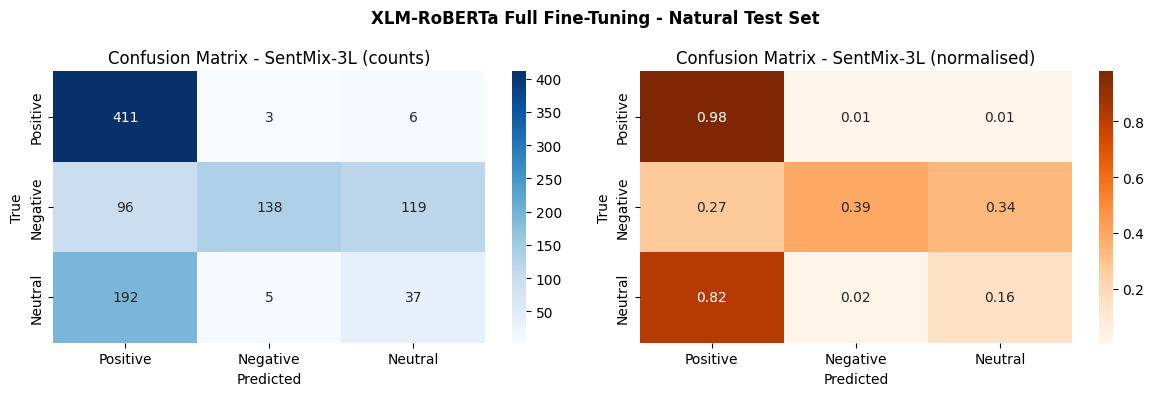

In [13]:
#Confusion matrix for primary test set
cm = confusion_matrix(y_true_nat, y_pred_nat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=axes[0])
axes[0].set_title("Confusion Matrix - SentMix-3L (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=axes[1])
axes[1].set_title("Confusion Matrix - SentMix-3L (normalised)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.suptitle("XLM-RoBERTa Full Fine-Tuning - Natural Test Set", fontweight="bold")
plt.tight_layout()
plt.show()

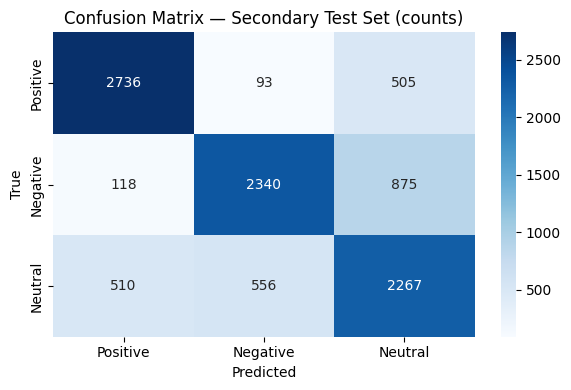

In [18]:
# Confusion matrix for secondary test set
cm_synth = confusion_matrix(y_true_synth, y_pred_synth)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_synth, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=ax)
ax.set_title("Confusion Matrix — Secondary Test Set (counts)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

In [14]:
#Results Summary

print("  FINAL RESULTS SUMMARY")
print(f"  Model              : {CONFIG['model_name']}")
print(f"  Approach           : Full Fine-Tuning")
print()
print("  Parameters ")
print(f"  Total params       : {total_params:>12,}")
print(f"  Trainable (all)    : {trainable_params:>12,}  ({pct:.1f}%)")
print(f"  Frozen             : {'0':>12}")
print()
print("  Training")
print(f"  Training data      : 30k samples")
print(f"  Epochs run         : (see early stopping log above)")
print(f"  Training time      : {elapsed:.1f}s  ({elapsed/60:.1f} min)")
print(f"  Batch size         : {CONFIG['batch_size']}")
print(f"  Learning rate      : {CONFIG['learning_rate']}")
print()
print("  Test Metrics (Primary test set)")
print(f"  Weighted F1        : {weighted_f1_nat:.4f}")
print(f"  Macro F1           : {macro_f1_nat:.4f}")
print(f"  Accuracy           : {accuracy_nat:.4f}")
print()
print("  Secondary test set")
print(f"  Weighted F1        : {report_synth['weighted avg']['f1-score']:.4f}")

#Save results
summary = {
    "model":    CONFIG["model_name"],
    "approach": "full_fine_tuning",
    "params": {
        "total":          total_params,
        "trainable":      trainable_params,
        "frozen":         0,
        "trainable_pct":  round(pct, 4),
    },
    "training": {
        "epochs_max":   CONFIG["num_epochs"],
        "time_sec":     round(elapsed, 2),
        "lr":           CONFIG["learning_rate"],
        "batch_size":   CONFIG["batch_size"],
        "train_samples": len(train_ds),
    },
    "natural_test_sentmix3l": {
        "weighted_f1": round(weighted_f1_nat, 4),
        "macro_f1":    round(macro_f1_nat, 4),
        "accuracy":    round(accuracy_nat, 4),
    },
    "synthetic_test": {
        "weighted_f1": round(report_synth["weighted avg"]["f1-score"], 4),
    },
    "confusion_matrix_natural": cm.tolist(),
}
with open("full_ft_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved as full_ft_results_summary.json")

  FINAL RESULTS SUMMARY
  Model              : xlm-roberta-base
  Approach           : Full Fine-Tuning

  Parameters 
  Total params       :  278,045,955
  Trainable (all)    :  278,045,955  (100.0%)
  Frozen             :            0

  Training
  Training data      : 30k samples
  Epochs run         : (see early stopping log above)
  Training time      : 1736.2s  (28.9 min)
  Batch size         : 32
  Learning rate      : 2e-05

  Test Metrics (Primary test set)
  Weighted F1        : 0.5437
  Macro F1           : 0.4915
  Accuracy           : 0.5819

  Secondary test set
  Weighted F1        : 0.7356

Saved as full_ft_results_summary.json


In [15]:
from google.colab import files

files.download("full_ft_results_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:

#Inference Demo

DEMO_SENTENCES = [
    ("আজকের দিনটা khub bhalo ছিল, I am so happy today!",          "Positive"),
    ("Aaj main bahut khush hoon কারণ আমার result ভালো হয়েছে!",   "Positive"),
    ("यह फिल्म একদম bakwas ছিল, worst movie I have ever seen.",    "Negative"),
    ("দিনটা বাজে গেছে, sab kuch galat ho gaya today.",              "Negative"),
    ("আবহাওয়া আজ theek hai, kuch khaas nahi.",                     "Neutral"),
    ("Main office গেছি, কাজ শেষ করলাম, ghar wapis aa gaya.",      "Neutral"),
]

import re, unicodedata

def quick_clean(text):
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

device = next(model.parameters()).device
model.eval()
print()
print(f"{'Input (truncated)':<44} {'True':>10} {'Pred':>10} {'Conf':>10}")

for text, true_label in DEMO_SENTENCES:
    clean = quick_clean(text)
    enc   = tokenizer(clean, return_tensors="pt", truncation=True,
                      max_length=CONFIG["max_length"], padding=True)
    enc   = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc)
    probs   = torch.softmax(out.logits, -1)
    pred_id = probs.argmax(-1).item()
    conf    = probs.max().item()
    match   = "✓" if ID2LABEL[pred_id] == true_label else "✗"
    print(f"{match} {text[:42]:<42} {true_label:>10} {ID2LABEL[pred_id]:>10} {conf:>6.1%}")





Input (truncated)                                  True       Pred       Conf
✓ আজকের দিনটা khub bhalo ছিল, I am so happy    Positive   Positive  93.9%
✓ Aaj main bahut khush hoon কারণ আমার result   Positive   Positive  67.0%
✓ यह फिल्म একদম bakwas ছিল, worst movie I ha   Negative   Negative  99.3%
✗ দিনটা বাজে গেছে, sab kuch galat ho gaya to   Negative    Neutral  88.3%
✓ আবহাওয়া আজ theek hai, kuch khaas nahi.       Neutral    Neutral  90.6%
✗ Main office গেছি, কাজ শেষ করলাম, ghar wapi    Neutral   Negative  40.5%


In [17]:
#Save Full Fine-Tuned Model

MODEL_SAVE_PATH = "/content/full_finetuned_model"
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

model_size_mb = sum(
    os.path.getsize(os.path.join(MODEL_SAVE_PATH, f))
    for f in os.listdir(MODEL_SAVE_PATH)
) / 1e6
print(f"Model saved : {MODEL_SAVE_PATH}")
print(f"Model size  : {model_size_mb:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved : /content/full_finetuned_model
Model size  : 1129.0 MB
